In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve,
                             classification_report, confusion_matrix)
from sklearn.calibration import calibration_curve
import warnings

import joblib
warnings.filterwarnings('ignore')

train = pd.read_parquet('../data/processed/train_woe.parquet')
oot   = pd.read_parquet('../data/processed/oot_woe.parquet')

TARGET = 'TARGET'
features = [c for c in train.columns if c != TARGET]

X_train = train[features]
y_train = train[TARGET]
X_oot   = oot[features]
y_oot   = oot[TARGET]

print(f"Train: {X_train.shape}, default rate: {y_train.mean():.3f}")
print(f"Holdout:   {X_oot.shape},   default rate: {y_oot.mean():.3f}")

Train: (246008, 56), default rate: 0.081
Holdout:   (61503, 56),   default rate: 0.081


In [2]:
# 计算KS值：好坏样本最大分离度，通过ROC曲线的TPR与FPR差值求得
def ks_stat(y_true, y_prob):
    """KS statistic – max separation between TPR and FPR curves."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return round(max(tpr - fpr), 4)

# 计算基尼系数，风控标准公式：Gini = 2*AUC - 1
def gini(y_true, y_prob):
    """Gini = 2*AUC - 1."""
    auc = roc_auc_score(y_true, y_prob)
    return round(2 * auc - 1, 4)

def evaluate(name, model, X_tr, y_tr, X_ot, y_ot):
    """Full evaluation on train and the stratified holdout."""
    # predict_proba输出[非违约概率,违约概率]，[:,1]取出第二类（逾期概率）
    p_tr = model.predict_proba(X_tr)[:, 1]
    p_ot = model.predict_proba(X_ot)[:, 1]

    results = {
        'Model'     : name,
        'AUC Train' : round(roc_auc_score(y_tr, p_tr), 4),
        'AUC Holdout'   : round(roc_auc_score(y_ot, p_ot), 4),
        'KS Train'  : ks_stat(y_tr, p_tr),
        'KS Holdout'    : ks_stat(y_ot, p_ot),
        'Gini Train': gini(y_tr, p_tr),
        'Gini Holdout'  : gini(y_ot, p_ot),
    }
    return results

In [3]:
# 分层基准模型：按照样本原始好坏比例随机预测（俄语注释翻译）
# Stratified dummy – 根据类别平衡随机预测
dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(X_train, y_train)
dummy_res = evaluate('DummyClassifier', dummy, X_train, y_train, X_oot, y_oot)
print(dummy_res)

{'Model': 'DummyClassifier', 'AUC Train': 0.5, 'AUC Holdout': 0.5016, 'KS Train': np.float64(0.0), 'KS Holdout': np.float64(0.0032), 'Gini Train': -0.0, 'Gini Holdout': 0.0032}


In [4]:
lr = LogisticRegression(
    C=1.0,                     # 正则化系数；C越小，正则越强，抑制过拟合
    class_weight='balanced',   # 自动给好坏样本分配权重，解决样本不均衡问题
    max_iter=1000,             # 最大迭代次数，保证模型收敛
    random_state=42,           # 固定随机种子，结果可复现
    solver='lbfgs'             # 优化算法，WOE特征场景最常用求解器
)
lr.fit(X_train, y_train)

# 将训练完成的LR模型保存到本地，后续制作评分卡、预测直接加载
joblib.dump(lr, '../models/logreg_woe.pkl')

lr_res = evaluate('Logistic Regression', lr, X_train, y_train, X_oot, y_oot)
print(lr_res)

{'Model': 'Logistic Regression', 'AUC Train': 0.7625, 'AUC Holdout': 0.7621, 'KS Train': np.float64(0.3941), 'KS Holdout': np.float64(0.3989), 'Gini Train': 0.5249, 'Gini Holdout': 0.5242}


In [5]:
results_df = pd.DataFrame([dummy_res, lr_res])
results_df = results_df.set_index('Model')
print(results_df.to_string())

                     AUC Train  AUC Holdout  KS Train  KS Holdout  Gini Train  Gini Holdout
Model                                                                                      
DummyClassifier         0.5000       0.5016    0.0000      0.0032     -0.0000        0.0032
Logistic Regression     0.7625       0.7621    0.3941      0.3989      0.5249        0.5242


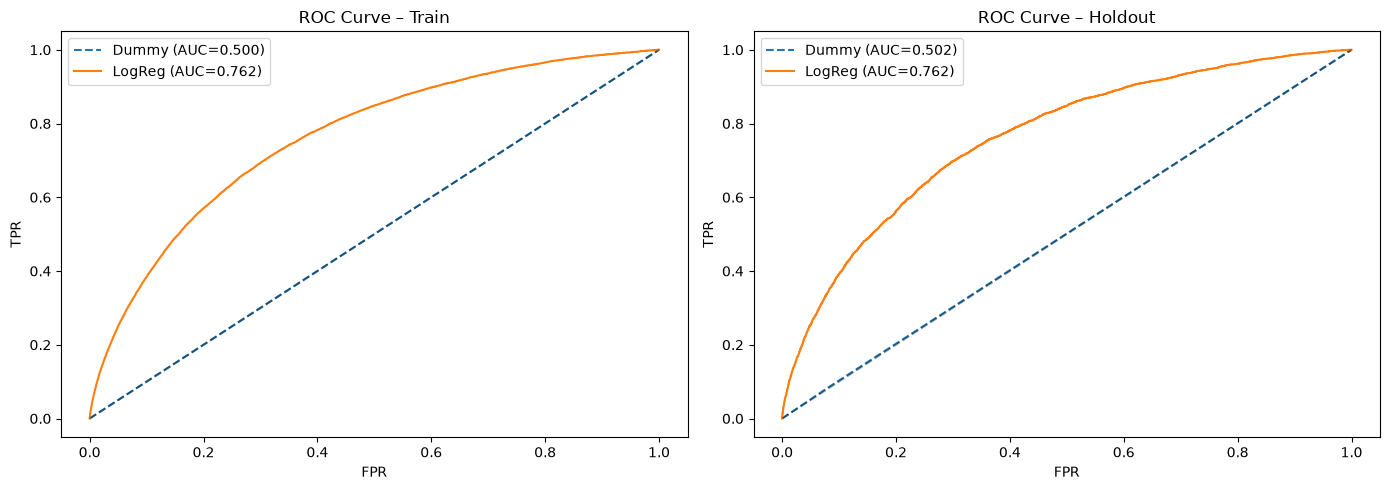

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (X, y, label) in zip(axes, [
    (X_train, y_train, 'Train'),
    (X_oot,   y_oot,   'Holdout')
]):
    fpr, tpr, _ = roc_curve(y, dummy.predict_proba(X)[:, 1])
    ax.plot(fpr, tpr, linestyle='--', label=f'Dummy (AUC={roc_auc_score(y, dummy.predict_proba(X)[:,1]):.3f})')

    fpr, tpr, _ = roc_curve(y, lr.predict_proba(X)[:, 1])
    ax.plot(fpr, tpr, label=f'LogReg (AUC={roc_auc_score(y, lr.predict_proba(X)[:,1]):.3f})')

    # 绘制对角线（AUC=0.5，无区分能力参考线）
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(f'ROC Curve – {label}')
    ax.set_xlabel('FPR')   # X轴：假正率（错杀好人的比例，越低越好）
    ax.set_ylabel('TPR')   # Y轴：真正率（抓到坏人的能力，越高越好）
    ax.legend()

plt.tight_layout()
plt.show()

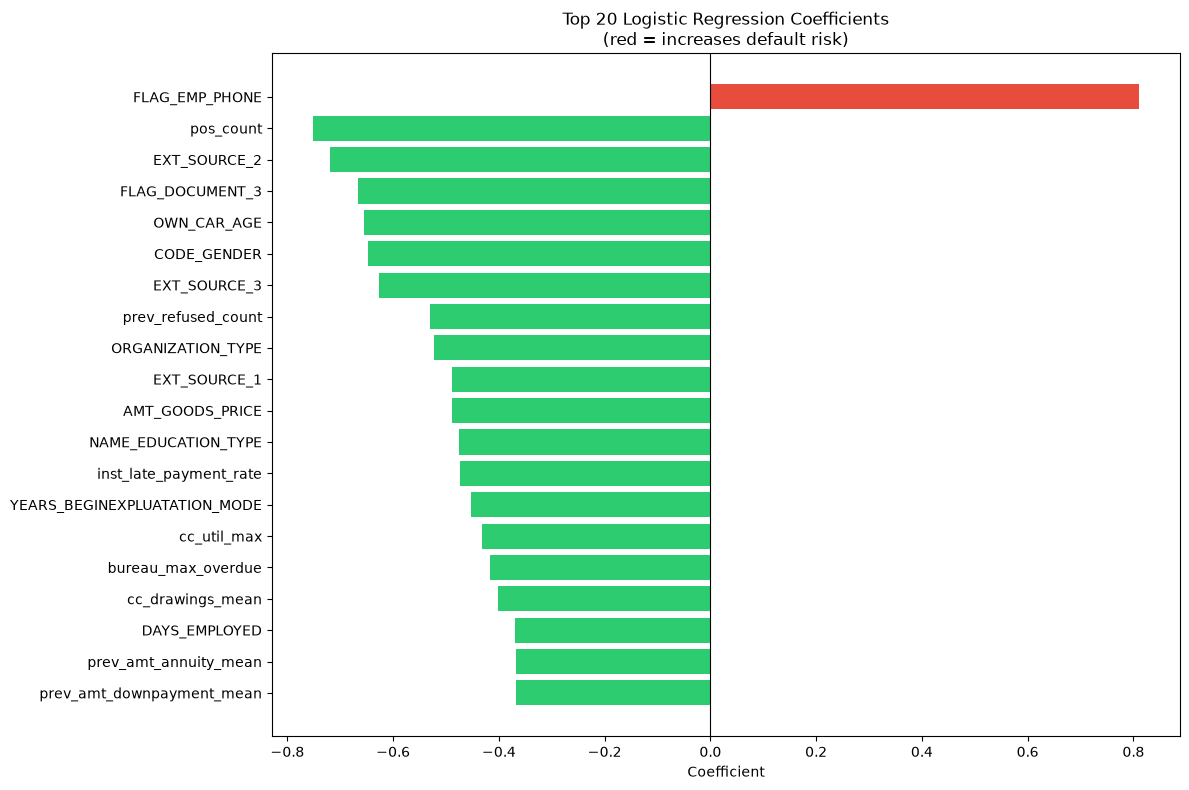

In [7]:
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': lr.coef_[0],
    'abs_coef': np.abs(lr.coef_[0])
}).sort_values('abs_coef', ascending=False)

plt.figure(figsize=(12, 8))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df.head(20)['coefficient']]
plt.barh(coef_df.head(20)['feature'], coef_df.head(20)['coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 20 Logistic Regression Coefficients\n(red = increases default risk)')
plt.xlabel('Coefficient')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()